**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import scipy
from scipy import stats
import seaborn as sns
from functools import reduce
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

/opt/miniconda3/envs/uniprot_notebook/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**Import processed file(s)**

Example processing with only one processed and filtered file:

In [3]:
df = pd.read_csv("./turbo_id_output/turbo_id_results_5_files/01_processed_files/processed_census-out_07142022_EV1-98_16pl_M.csv")

In [4]:
#Rename columns according to conditions
df.columns = ["uniprot", 
              "description", 
              "pep_num", 
              "ctrl_turbo(-)_1",
              "ctrl_turbo(-)_2",
              "LPS_turbo(-)_1",
              "LPS_turbo(-)_2",
              "fast_turbo(-)_1",
              "fast_turbo(-)_2",
              "ctrl_turbo(+)_1",
              "ctrl_turbo(+)_2",
              "ctrl_turbo(+)_3",
              "LPS_turbo(+)_1",
              "LPS_turbo(+)_2",
              "LPS_turbo(+)_3",
              "fast_turbo(+)_1",
              "fast_turbo(+)_2",
              "fast_turbo(+)_3",
              "fast_turbo(+)_4",
             ]



In [5]:
#Prepare table for processing
df = df.set_index(["uniprot", 'description', 'pep_num'])

**The file contains a table of averaged raw signal intensities**

In [7]:
df.head()

,,,ctrl_turbo(-)_1,ctrl_turbo(-)_2,LPS_turbo(-)_1,LPS_turbo(-)_2,fast_turbo(-)_1,fast_turbo(-)_2,ctrl_turbo(+)_1,ctrl_turbo(+)_2,ctrl_turbo(+)_3,LPS_turbo(+)_1,LPS_turbo(+)_2,LPS_turbo(+)_3,fast_turbo(+)_1,fast_turbo(+)_2,fast_turbo(+)_3,fast_turbo(+)_4
uniprot,description,pep_num,,,,,,,,,,,,,,,,
Q8BWT1,"Acaa2 3-ketoacyl-CoA thiolase, mitochondrial",35,36678.5,30948.0,40683.0,14958.5,14231.5,12992.0,10666.0,10621.5,18305.5,13276.0,33184.0,34873.0,13494.5,12409.0,8704.5,6658.5
E9QPD7,Pcx Pyruvate carboxylase,97,27279.0,31536.5,32276.0,19159.5,23517.0,32187.0,33525.0,25879.0,38986.5,40384.5,21927.5,36981.0,38488.5,31972.5,24189.5,25406.0
Q91ZA3,"Pcca Propionyl-CoA carboxylase alpha chain, mitochondrial",63,37450.5,29692.0,72133.0,10690.5,33932.0,28925.0,43875.5,33606.0,46231.0,48309.0,40737.5,58439.0,76645.5,56094.5,37565.0,40221.5
Q8C196,Cps1 Carbamoyl-phosphate synthase,109,31471.5,27621.5,34175.5,22349.0,21441.0,31095.5,27077.5,21482.0,33059.0,31673.0,26184.5,30480.0,38360.0,27818.0,14328.0,19985.5
P16460,Ass1 Argininosuccinate synthase,31,47282.5,35183.5,37115.5,24324.0,21807.0,31954.5,23203.0,20143.0,28650.5,32629.5,37185.5,46163.5,31634.5,22692.0,16508.0,19808.0


**Calculate ratios**

- we have 2 different conditions in this file and we need to treat them seperately (HF and chow)
- each od these conditions contains treatments(cre+) and controls(cre-)
- we divide each treatment with each control 

In [9]:
def get_ratio_df(df, condition_name):

    filtered_df = df.filter(regex=condition_name)

    cond_columns = filtered_df.filter(like='(+)').columns.tolist()
    ctrl_columns = filtered_df.filter(like='(-)').columns.tolist()

    for condition in cond_columns:
        for control in ctrl_columns:
            filtered_df[condition+"/"+control+"_ratio"] = filtered_df[condition] / filtered_df[control]
        
    df_ratio = filtered_df.filter(regex='_ratio')
    return(df_ratio)
    

In [11]:
ctrl_turbo_df = get_ratio_df(df, "ctrl_turbo")
ctrl_turbo_df.head()

,,,ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio,ctrl_turbo(+)_2/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_2/ctrl_turbo(-)_2_ratio,ctrl_turbo(+)_3/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_3/ctrl_turbo(-)_2_ratio
uniprot,description,pep_num,,,,,,
Q8BWT1,"Acaa2 3-ketoacyl-CoA thiolase, mitochondrial",35,0.290797,0.344643,0.289584,0.343205,0.499080,0.591492
E9QPD7,Pcx Pyruvate carboxylase,97,1.228967,1.063054,0.948678,0.820605,1.429176,1.236234
Q91ZA3,"Pcca Propionyl-CoA carboxylase alpha chain, mitochondrial",63,1.171560,1.477688,0.897344,1.131820,1.234456,1.557019
Q8C196,Cps1 Carbamoyl-phosphate synthase,109,0.860382,0.980305,0.682586,0.777727,1.050442,1.196858
P16460,Ass1 Argininosuccinate synthase,31,0.490731,0.659485,0.426014,0.572513,0.605943,0.814316


In [17]:
LPS_turbo_df = get_ratio_df(df, "LPS_turbo")
LPS_turbo_df.head()

,,,LPS_turbo(+)_1/LPS_turbo(-)_1_ratio,LPS_turbo(+)_1/LPS_turbo(-)_2_ratio,LPS_turbo(+)_2/LPS_turbo(-)_1_ratio,LPS_turbo(+)_2/LPS_turbo(-)_2_ratio,LPS_turbo(+)_3/LPS_turbo(-)_1_ratio,LPS_turbo(+)_3/LPS_turbo(-)_2_ratio
uniprot,description,pep_num,,,,,,
Q8BWT1,"Acaa2 3-ketoacyl-CoA thiolase, mitochondrial",35,0.326328,0.887522,0.815672,2.218404,0.857189,2.331317
E9QPD7,Pcx Pyruvate carboxylase,97,1.251224,2.107806,0.679375,1.144471,1.145774,1.930165
Q91ZA3,"Pcca Propionyl-CoA carboxylase alpha chain, mitochondrial",63,0.669721,4.518872,0.564755,3.810626,0.810156,5.466442
Q8C196,Cps1 Carbamoyl-phosphate synthase,109,0.926775,1.417200,0.766178,1.171618,0.891867,1.363819
P16460,Ass1 Argininosuccinate synthase,31,0.879134,1.341453,1.001886,1.528758,1.243780,1.897858


In [13]:
fast_turbo_df = get_ratio_df(df, "fast_turbo")
fast_turbo_df.head()

,,,fast_turbo(+)_1/fast_turbo(-)_1_ratio,fast_turbo(+)_1/fast_turbo(-)_2_ratio,fast_turbo(+)_2/fast_turbo(-)_1_ratio,fast_turbo(+)_2/fast_turbo(-)_2_ratio,fast_turbo(+)_3/fast_turbo(-)_1_ratio,fast_turbo(+)_3/fast_turbo(-)_2_ratio,fast_turbo(+)_4/fast_turbo(-)_1_ratio,fast_turbo(+)_4/fast_turbo(-)_2_ratio
uniprot,description,pep_num,,,,,,,,
Q8BWT1,"Acaa2 3-ketoacyl-CoA thiolase, mitochondrial",35,0.948213,1.038678,0.871939,0.955126,0.611636,0.669989,0.467871,0.512508
E9QPD7,Pcx Pyruvate carboxylase,97,1.636625,1.195778,1.359548,0.993336,1.028596,0.751530,1.080325,0.789325
Q91ZA3,"Pcca Propionyl-CoA carboxylase alpha chain, mitochondrial",63,2.258797,2.649801,1.653145,1.939309,1.107067,1.298704,1.185356,1.390545
Q8C196,Cps1 Carbamoyl-phosphate synthase,109,1.789096,1.233619,1.297421,0.894599,0.668252,0.460774,0.932116,0.642714
P16460,Ass1 Argininosuccinate synthase,31,1.450658,0.989986,1.040583,0.710135,0.757005,0.516610,0.908332,0.619881


In [18]:
condition_tables = [ctrl_turbo_df, LPS_turbo_df, fast_turbo_df]

**Annotate each condition table with TP and FP lists**

- if uniprot id is in TP list the annotation column will be filled with "TP" 
- if uniprot id is in FP list the annotation column will be filled with "FP" 
- if uniprot id is in any of them annotation column will be filled with "None"

In [19]:
#get lists
FP_df = pd.read_csv("./uniprot_noteboook/combine_uniprot_IDs_per_species/mouse/00_combined/mouse_FP_list_cyt_nuc_TFs.csv")
FP_list = FP_df["Entry"].tolist()
print("Number of Uniport IDs in FP list:", len(FP_list))
TP_df = pd.read_csv("./uniprot_noteboook/combine_uniprot_IDs_per_species/mouse/00_combined/mouse_TP_list_secreted.csv")
TP_list = TP_df["Entry"].tolist()
print("Number of Uniport IDs in TP list:", len(TP_list))

Number of Uniport IDs in FP list: 8342
Number of Uniport IDs in TP list: 6952


In [20]:
def annotate_uniprot(uniprot_id):
    if uniprot_id in TP_list:
        return "TP"
    elif uniprot_id in FP_list:
        return "FP"

In [21]:
annotated_tables = []
for table in condition_tables:
    table = table.reset_index()
    uniprot_ids = table["uniprot"]
    table["annotation"] = table["uniprot"].apply(annotate_uniprot)
    table = table.set_index(["uniprot", 'description', 'pep_num', 'annotation'])
    annotated_tables.append(table)

print("Example for one condition:")
annotated_tables[0].head()

Example for one condition:


,,,,ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio,ctrl_turbo(+)_2/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_2/ctrl_turbo(-)_2_ratio,ctrl_turbo(+)_3/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_3/ctrl_turbo(-)_2_ratio
uniprot,description,pep_num,annotation,,,,,,
Q8BWT1,"Acaa2 3-ketoacyl-CoA thiolase, mitochondrial",35,NaN,0.290797,0.344643,0.289584,0.343205,0.499080,0.591492
E9QPD7,Pcx Pyruvate carboxylase,97,NaN,1.228967,1.063054,0.948678,0.820605,1.429176,1.236234
Q91ZA3,"Pcca Propionyl-CoA carboxylase alpha chain, mitochondrial",63,NaN,1.171560,1.477688,0.897344,1.131820,1.234456,1.557019
Q8C196,Cps1 Carbamoyl-phosphate synthase,109,FP,0.860382,0.980305,0.682586,0.777727,1.050442,1.196858
P16460,Ass1 Argininosuccinate synthase,31,NaN,0.490731,0.659485,0.426014,0.572513,0.605943,0.814316


For the next steps we followed methods section "Data analysis" of https://www.nature.com/articles/s41596-020-0399-0

- Analyze each replicate seperately

- Normalize corresponding TMT ratios against the distribution of FP proteins that should not be biotinylated by TurboID (FP list). To do this, divide all TMT ratios by the median of the ratios for FP proteins.

- Calculate the log2 value of each ratio; log2 values will be used for the rest of the analysis. This normalization centers the distribution of the log2 ratios of nonspecifically binding proteins around 0.

- Check the correlation between replicates by plotting the corresponding log2 ratios. 

- Rank the proteins by the appropriate TMT ratio values in descending order and cross this list with the TP and FP lists to determine which proteins are TPs and FPs, respectively.

- At each potential cutoff, calculate the TPR and FP rate (FPR), where the TPR/FPR is defined as the number of detected TP/FP proteins detected above the cutoff divided by the total number of detected TP/FP proteins in that replicate. A plot of the TPR versus the FPR should show that the curve bows out as compared with the diagonal, which shows that the proteomic experiment successfully enriched TP proteins over FP proteins (Fig. 4c).

- Determine the cutoff by using the log2 ratio that corresponds to the maximum TPR-FPR value. In cases in which the list of TP proteins is small (e.g., ER–mitochondria contacts; Fig. 5a–d), the cutoff can be alternatively determined with a FDR cutoff (Fig. 5d), where FDR is defined as the fraction of FP proteins detected above each cutoff.

- Retain all proteins with log2 ratios higher than that of the determined cutoff.

Analyzing:  ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio
     uniprot annotation  ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio  original_ratio
1992  Q8C5P7         FP                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
Number of proteins without nans for ratio: 2914
Number of annotated TP:  224
Number of annotated FP:  717


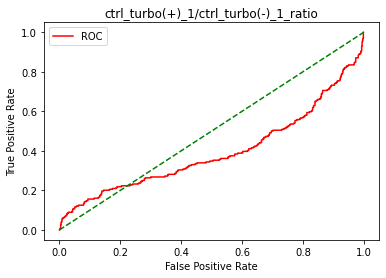

Cutoff value: 0.7354223904008175


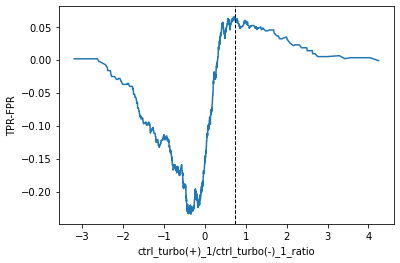

Analyzing:  ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio
     uniprot annotation  ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio  original_ratio
1494  B2RT14        NaN                                    NaN             NaN
2024  O09131        NaN                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2912
Number of annotated TP:  224
Number of annotated FP:  718


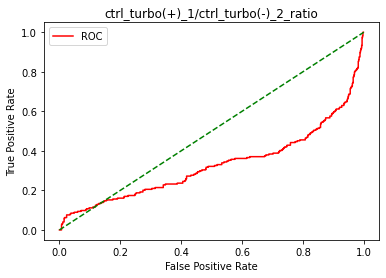

Cutoff value: 1.2378976220460614


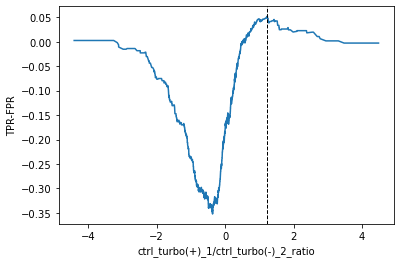

Analyzing:  ctrl_turbo(+)_2/ctrl_turbo(-)_1_ratio
     uniprot annotation  ctrl_turbo(+)_2/ctrl_turbo(-)_1_ratio  original_ratio
1345  Q3U276        NaN                                    NaN             NaN
1992  Q8C5P7         FP                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
2586  Q9DBL2        NaN                                    NaN             NaN
2720  E9Q1U6        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2911
Number of annotated TP:  224
Number of annotated FP:  717


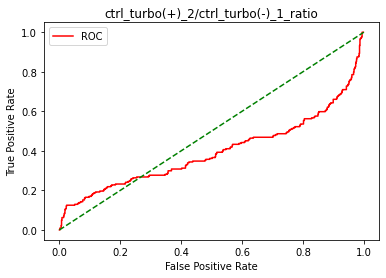

Cutoff value: 1.0214559005695034


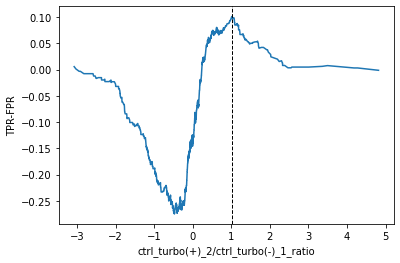

Analyzing:  ctrl_turbo(+)_2/ctrl_turbo(-)_2_ratio
     uniprot annotation  ctrl_turbo(+)_2/ctrl_turbo(-)_2_ratio  original_ratio
1494  B2RT14        NaN                                    NaN             NaN
2052  Q9CTH6         FP                                    NaN             NaN
2507  Q91YE3         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2911
Number of annotated TP:  224
Number of annotated FP:  716


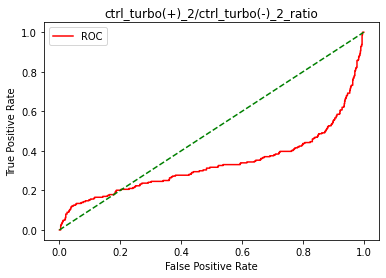

Cutoff value: 1.0157537806659704


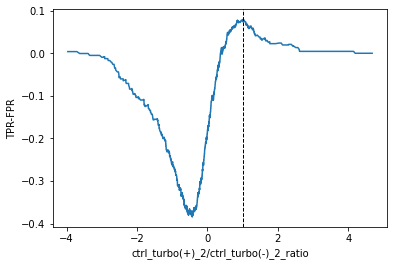

Analyzing:  ctrl_turbo(+)_3/ctrl_turbo(-)_1_ratio
Empty DataFrame
Columns: [uniprot, annotation, ctrl_turbo(+)_3/ctrl_turbo(-)_1_ratio, original_ratio]
Index: []
Number of proteins without nans for ratio: 2916
Number of annotated TP:  224
Number of annotated FP:  719


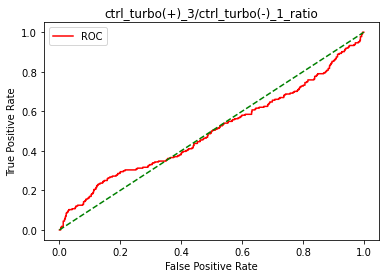

Cutoff value: 0.5352748711866687


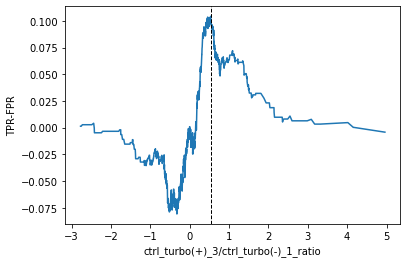

Analyzing:  ctrl_turbo(+)_3/ctrl_turbo(-)_2_ratio
     uniprot annotation  ctrl_turbo(+)_3/ctrl_turbo(-)_2_ratio  original_ratio
1787  P35290        NaN                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2913
Number of annotated TP:  224
Number of annotated FP:  718


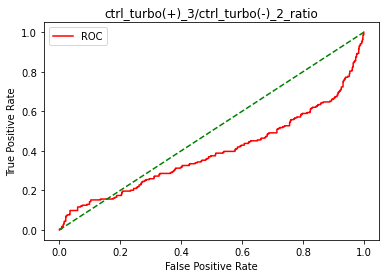

Cutoff value: 1.0198744460016


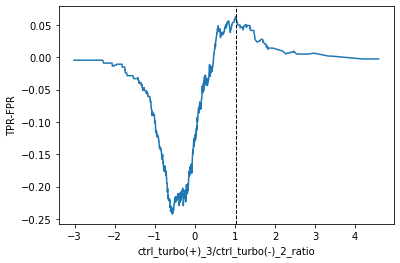

Analyzing:  LPS_turbo(+)_1/LPS_turbo(-)_1_ratio
     uniprot annotation  LPS_turbo(+)_1/LPS_turbo(-)_1_ratio  original_ratio
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2915
Number of annotated TP:  224
Number of annotated FP:  719


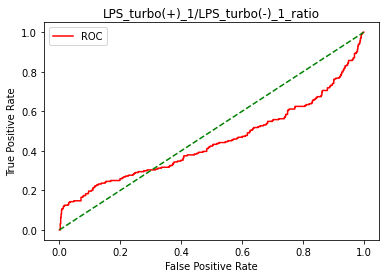

Cutoff value: 1.077162229958909


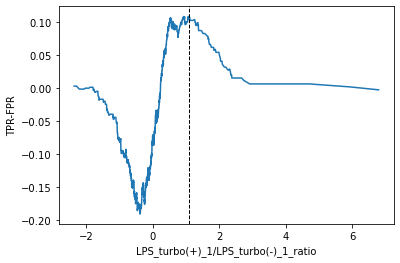

Analyzing:  LPS_turbo(+)_1/LPS_turbo(-)_2_ratio
     uniprot annotation  LPS_turbo(+)_1/LPS_turbo(-)_2_ratio  original_ratio
1787  P35290        NaN                                  NaN             NaN
2702  Q5F2E7         FP                                  NaN             NaN
2740  P42128         FP                                  NaN             NaN
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2912
Number of annotated TP:  224
Number of annotated FP:  717


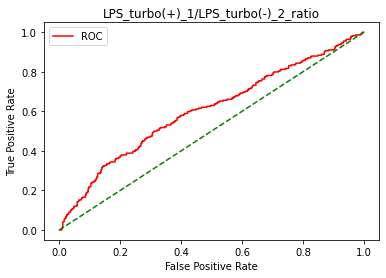

Cutoff value: 0.2789020470230606


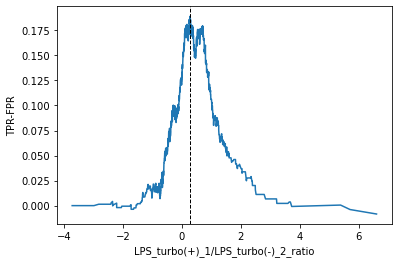

Analyzing:  LPS_turbo(+)_2/LPS_turbo(-)_1_ratio
     uniprot annotation  LPS_turbo(+)_2/LPS_turbo(-)_1_ratio  original_ratio
2263  Q6NVE9        NaN                                  NaN             NaN
2519  P70459         FP                                  NaN             NaN
2638  Q11136        NaN                                  NaN             NaN
2720  E9Q1U6        NaN                                  NaN             NaN
2735  Q8CEC0         FP                                  NaN             NaN
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2910
Number of annotated TP:  224
Number of annotated FP:  717


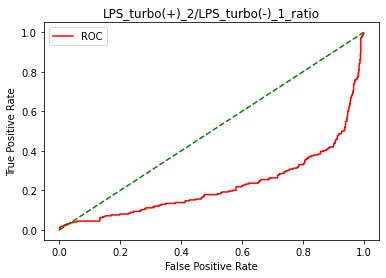

Cutoff value: 1.2288767214726102


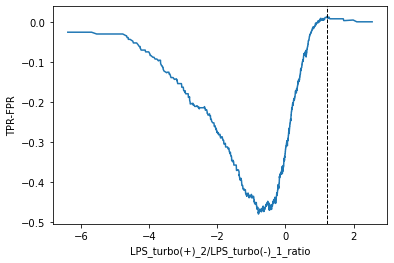

Analyzing:  LPS_turbo(+)_2/LPS_turbo(-)_2_ratio
     uniprot annotation  LPS_turbo(+)_2/LPS_turbo(-)_2_ratio  original_ratio
1345  Q3U276        NaN                                  NaN             NaN
1494  B2RT14        NaN                                  NaN             NaN
2168  Q80WR5         FP                                  NaN             NaN
2263  Q6NVE9        NaN                                  NaN             NaN
2435  Q9D8V0        NaN                                  NaN             NaN
2653  Q9Z2A0         FP                                  NaN             NaN
2702  Q5F2E7         FP                                  NaN             NaN
2735  Q8CEC0         FP                                  NaN             NaN
2858  E9PXF8        NaN                                  NaN             NaN
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2906
Number of annotated TP:  224
Number of annotated FP:  715

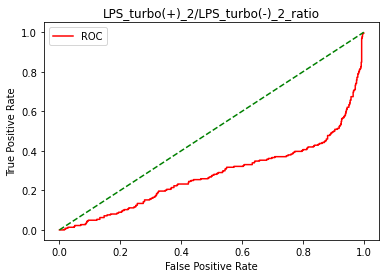

Cutoff value: inf


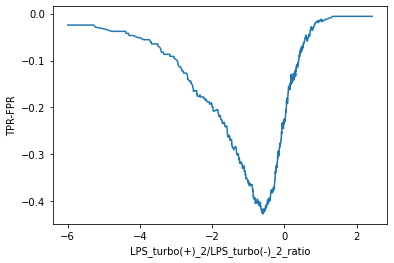

Analyzing:  LPS_turbo(+)_3/LPS_turbo(-)_1_ratio
     uniprot annotation  LPS_turbo(+)_3/LPS_turbo(-)_1_ratio  original_ratio
2519  P70459         FP                                  NaN             NaN
2735  Q8CEC0         FP                                  NaN             NaN
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2913
Number of annotated TP:  224
Number of annotated FP:  717


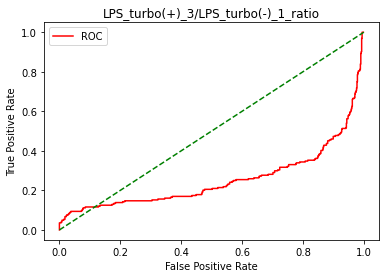

Cutoff value: 0.8139150538350035


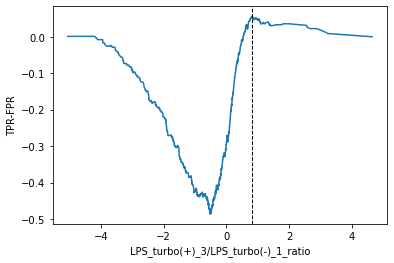

Analyzing:  LPS_turbo(+)_3/LPS_turbo(-)_2_ratio
     uniprot annotation  LPS_turbo(+)_3/LPS_turbo(-)_2_ratio  original_ratio
1494  B2RT14        NaN                                  NaN             NaN
1512  Q6PGH1         FP                                  NaN             NaN
1787  P35290        NaN                                  NaN             NaN
2653  Q9Z2A0         FP                                  NaN             NaN
2702  Q5F2E7         FP                                  NaN             NaN
2735  Q8CEC0         FP                                  NaN             NaN
2740  P42128         FP                                  NaN             NaN
2882  Q99KY4        NaN                                  NaN             NaN
Number of proteins without nans for ratio: 2908
Number of annotated TP:  224
Number of annotated FP:  714


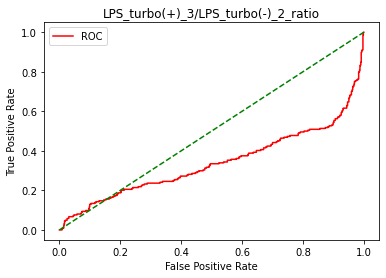

Cutoff value: 1.0813891847706698


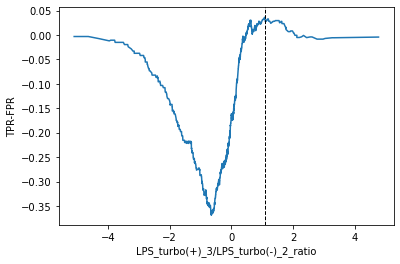

Analyzing:  fast_turbo(+)_1/fast_turbo(-)_1_ratio
     uniprot annotation  fast_turbo(+)_1/fast_turbo(-)_1_ratio  original_ratio
1992  Q8C5P7         FP                                    NaN             NaN
2435  Q9D8V0        NaN                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2837  Q80XR2        NaN                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2910
Number of annotated TP:  224
Number of annotated FP:  716


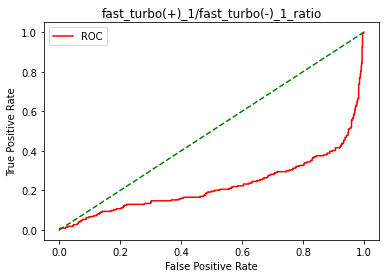

Cutoff value: inf


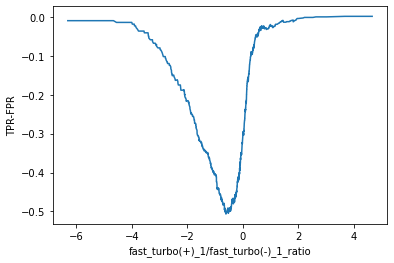

Analyzing:  fast_turbo(+)_1/fast_turbo(-)_2_ratio
     uniprot annotation  fast_turbo(+)_1/fast_turbo(-)_2_ratio  original_ratio
2548  Q61398         TP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2912
Number of annotated TP:  223
Number of annotated FP:  717


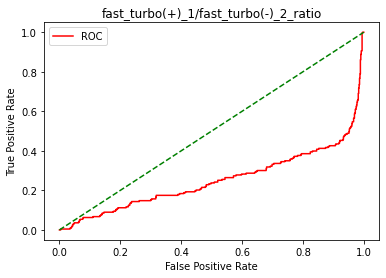

Cutoff value: -inf


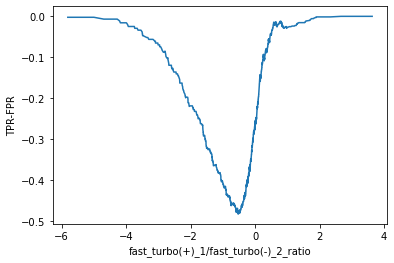

Analyzing:  fast_turbo(+)_2/fast_turbo(-)_1_ratio
     uniprot annotation  fast_turbo(+)_2/fast_turbo(-)_1_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2735  Q8CEC0         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2910
Number of annotated TP:  224
Number of annotated FP:  714


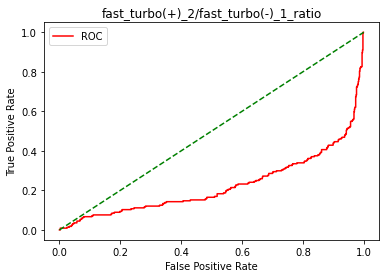

Cutoff value: inf


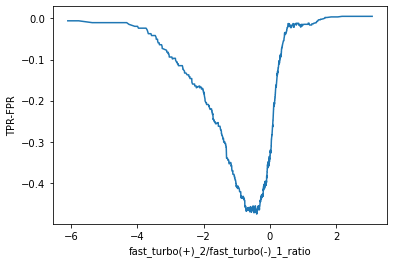

Analyzing:  fast_turbo(+)_2/fast_turbo(-)_2_ratio
     uniprot annotation  fast_turbo(+)_2/fast_turbo(-)_2_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2735  Q8CEC0         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2910
Number of annotated TP:  224
Number of annotated FP:  714


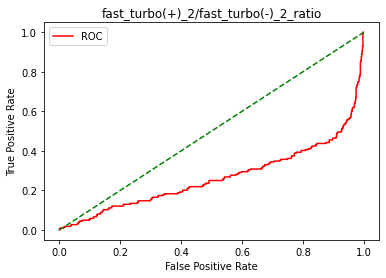

Cutoff value: inf


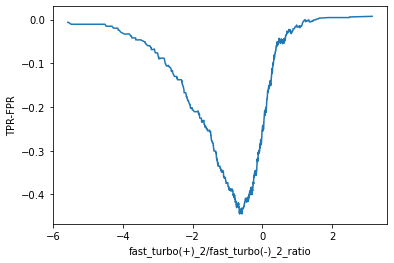

Analyzing:  fast_turbo(+)_3/fast_turbo(-)_1_ratio
     uniprot annotation  fast_turbo(+)_3/fast_turbo(-)_1_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
1948  Q8C3I8        NaN                                    NaN             NaN
2168  Q80WR5         FP                                    NaN             NaN
2271  Q8JZY4        NaN                                    NaN             NaN
2435  Q9D8V0        NaN                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2837  Q80XR2        NaN                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2906
Number of annotated TP:  224
Numb

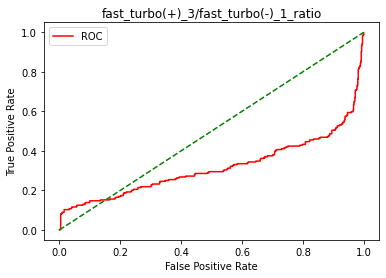

Cutoff value: 1.582282216415701


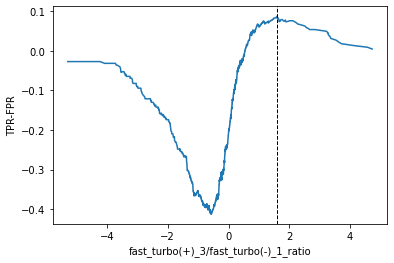

Analyzing:  fast_turbo(+)_3/fast_turbo(-)_2_ratio
     uniprot annotation  fast_turbo(+)_3/fast_turbo(-)_2_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
2168  Q80WR5         FP                                    NaN             NaN
2498  Q8BH15         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2846  Q7TQG1        NaN                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2909
Number of annotated TP:  224
Number of annotated FP:  714


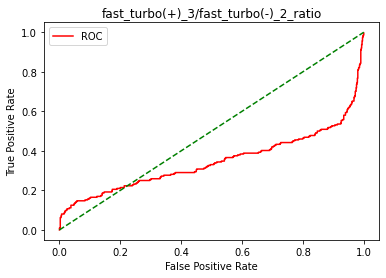

Cutoff value: 0.9499487724639346


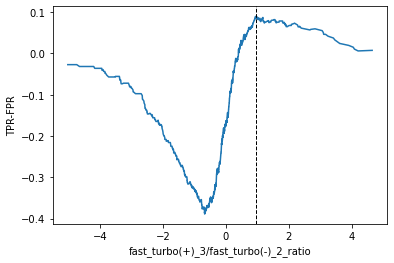

Analyzing:  fast_turbo(+)_4/fast_turbo(-)_1_ratio
     uniprot annotation  fast_turbo(+)_4/fast_turbo(-)_1_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
1992  Q8C5P7         FP                                    NaN             NaN
2271  Q8JZY4        NaN                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2735  Q8CEC0         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2909
Number of annotated TP:  224
Number of annotated FP:  714


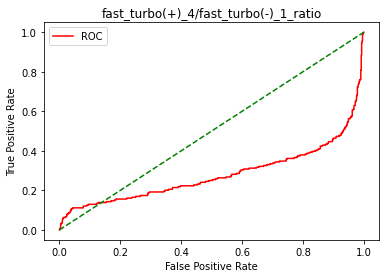

Cutoff value: 1.115105469213882


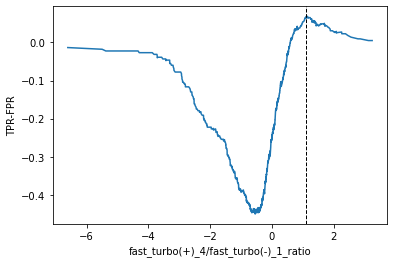

Analyzing:  fast_turbo(+)_4/fast_turbo(-)_2_ratio
     uniprot annotation  fast_turbo(+)_4/fast_turbo(-)_2_ratio  original_ratio
1512  Q6PGH1         FP                                    NaN             NaN
2702  Q5F2E7         FP                                    NaN             NaN
2735  Q8CEC0         FP                                    NaN             NaN
2740  P42128         FP                                    NaN             NaN
2882  Q99KY4        NaN                                    NaN             NaN
Number of proteins without nans for ratio: 2911
Number of annotated TP:  224
Number of annotated FP:  715


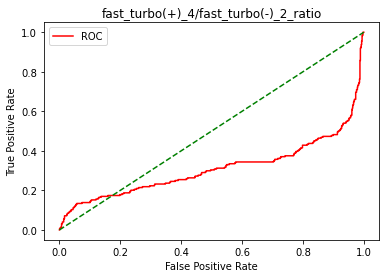

Cutoff value: 0.9723735095755317


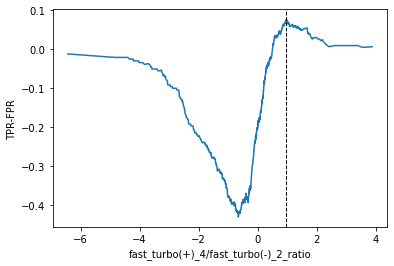

In [22]:
all_cond_cutoff_tables = []
condition_table = []

for table in annotated_tables:
    condition_cutoff_table = []
    
    columns_list = table.columns.tolist()
    
    table = table.reset_index()
    
    for column in columns_list:
        
        #get replicate
        df_rep = table[["uniprot", "annotation", column]]
        
        print("Analyzing: ", column)
        #print("Number of proteins with nans:", df_rep.shape[0])
        
        #normalize ratios
        df_rep["original_ratio"] = df_rep[column]
        median_FP_ratio = df_rep.loc[df_rep['annotation'] == 'FP', column].median()
        df_rep[column] = df_rep[column].div(median_FP_ratio)
        df_rep[column] = np.log2(df_rep[column]) 

        #remove infs and nas
        #df_rep[column].replace([np.inf, -np.inf], np.nan, inplace=True)
        #df_rep[column].replace([np.inf], np.nan, inplace=True)
        
        print(df_rep[df_rep[column].isna()])
        df_rep = df_rep[df_rep[column].notna()]
        
        print("Number of proteins without nans for ratio:", df_rep.shape[0])
        #get total number of annotated TP and FP
        total_TP = len(df_rep[df_rep["annotation"] == "TP"])
        total_FP = len(df_rep[df_rep["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        
        #rank ratio in descending order
        df_rep = df_rep.sort_values(column, ascending=False)
        
        #clean up index
        df_rep = df_rep.reset_index(drop=True)
        #get index as list
        index_list = df_rep.index.values.tolist()
        
        #for each row calculate number of TP and FP in all the rows before
        for row_number in index_list:
            if row_number == 0:
                df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                df_rep.loc[df_rep.index[row_number], 'TP'] = 0
            
            else:
                results_dict = {}
                subset_df = df_rep.loc[0:row_number-1]
                for idx, name in enumerate(subset_df.annotation.value_counts().index.tolist()):
                    results_dict[name] = subset_df.annotation.value_counts()[idx]

                if 'FP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = results_dict["FP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'FP'] = 0
                if 'TP' in results_dict:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = results_dict["TP"]
                else:
                    df_rep.loc[df_rep.index[row_number], 'TP'] = 0

        #calculate TPR and FPR
        df_rep["TPR"] = df_rep["TP"] / total_TP
        df_rep["FPR"] = df_rep["FP"] / total_FP
        
        #plot TPR and FPR 
        plt.plot(df_rep["FPR"], df_rep["TPR"], color='red', label='ROC')
        plt.plot([0, 1], [0, 1], color='green', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(column)
        plt.legend()
        plt.show()
        
        #calculate TPR-FPR, get cutoff value = maximum TPR-FPR value
        df_rep["TPR-FPR"] = df_rep["TPR"] - df_rep["FPR"]
        cutoff_value = df_rep.loc[df_rep["TPR-FPR"].idxmax()][column]
        print("Cutoff value:", cutoff_value)
    
        #plot log2 ratio and TPR-FPR
        ax = sns.lineplot(df_rep[column], df_rep["TPR-FPR"])
    
        #xlabel_string = "Log2(" + column + ")"
        # Setting the X and Y Label
        #ax.set_xlabel(xlabel_string)
        ax.set_xlabel(column)
        ax.set_ylabel('TPR-FPR')
        ax.axvline(cutoff_value, linewidth=1, color="black", linestyle = "--")
        plt.show()
    
        #Retain all proteins with log2 ratios higher than that of the determined cutoff
        df_rep_cutoff = df_rep[df_rep[column] > cutoff_value]
        #df_rep_cutoff = df_rep[df_rep["FPR"] < 0.1] FDR 10 %
        
        condition_cutoff_table.append(df_rep_cutoff)
        condition_table.append(df_rep)
        #print(df_rep[column].min())
        #column = column.replace("/", "-")
        #filename = column +".csv"
        #df_rep.to_csv(filename)
        #rep_protein_dfs_which_pass_cutoff.append(df_rep)

    all_cond_cutoff_tables.append(condition_cutoff_table)

**Example of a replicate table**

In [23]:
df_rep.head()

,uniprot,annotation,fast_turbo(+)_4/fast_turbo(-)_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
0,Q8R0Z6,TP,inf,inf,0.0,0.0,0.000000,0.000000,0.000000
1,Q3U276,NaN,inf,inf,0.0,1.0,0.004464,0.000000,0.004464
2,Q11136,NaN,inf,inf,0.0,1.0,0.004464,0.000000,0.004464
3,Q8BH15,FP,inf,inf,0.0,1.0,0.004464,0.000000,0.004464
4,Q7TQG1,NaN,inf,inf,1.0,1.0,0.004464,0.001399,0.003066


In [24]:
df_rep.tail()

,uniprot,annotation,fast_turbo(+)_4/fast_turbo(-)_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
2906,Q63880,NaN,-inf,0.0,713.0,224.0,1.0,0.997203,0.002797
2907,P98203,FP,-inf,0.0,713.0,224.0,1.0,0.997203,0.002797
2908,Q6P1G0,NaN,-inf,0.0,714.0,224.0,1.0,0.998601,0.001399
2909,Q8C5P7,FP,-inf,0.0,714.0,224.0,1.0,0.998601,0.001399
2910,Q9WTR5,NaN,-inf,0.0,715.0,224.0,1.0,1.000000,0.000000


In [25]:
df_rep.describe()

,fast_turbo(+)_4/fast_turbo(-)_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
count,2911.000000,2911.000000,2911.000000,2911.000000,2911.000000,2911.000000,2911.000000
mean,NaN,inf,419.333562,83.290622,0.371833,0.586481,-0.214647
std,NaN,NaN,219.160287,44.308424,0.197805,0.306518,0.158451
min,-inf,0.000000,0.000000,0.000000,0.000000,0.000000,-0.431144
25%,-0.536130,0.658196,227.500000,52.000000,0.232143,0.318182,-0.379496
50%,-0.147694,0.861562,443.000000,77.000000,0.343750,0.619580,-0.228759
75%,0.214852,1.107703,621.000000,106.000000,0.473214,0.868531,-0.064467
max,inf,inf,715.000000,224.000000,1.000000,1.000000,0.076586


In [218]:
#df_rep["original_ratio"].plot.box()

**Example subset of proteins above cutoff**

In [26]:
print("Cutoff:", cutoff_value)

Cutoff: 0.9723735095755317


In [27]:
df_rep_cutoff.describe()

,fast_turbo(+)_4/fast_turbo(-)_2_ratio,original_ratio,FP,TP,TPR,FPR,TPR-FPR
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,inf,inf,19.528571,16.692857,0.074522,0.027313,0.047209
std,NaN,NaN,11.753734,8.204137,0.036626,0.016439,0.021041
min,0.972447,1.872761,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.169119,2.146292,10.000000,10.750000,0.047991,0.013986,0.034005
50%,1.363810,2.456380,19.000000,19.000000,0.084821,0.026573,0.054914
75%,1.786469,3.292617,28.000000,23.000000,0.102679,0.039161,0.060184
max,inf,inf,41.000000,29.000000,0.129464,0.057343,0.074919


In [223]:
#df_rep_cutoff["original_ratio"].plot.box()

**For each replicate get number of proteins that pass cutoff**

In [28]:
print("Proteins that pass cutoff:")
print("")

for condition_tables in all_cond_cutoff_tables:
    for table in condition_tables:
        col_name = table.columns.tolist()[-7]
        print(col_name)
        print("Number of proteins", table.shape[0])
        #get total number of annotated TP and FP
        total_TP = len(table[table["annotation"] == "TP"])
        total_FP = len(table[table["annotation"] == "FP"])
        print("Number of annotated TP: ", total_TP)
        print("Number of annotated FP: ", total_FP)
        print("")
        table.rename(columns={"FP": "FP_"+col_name, 
                              "TP": "TP_"+col_name, 
                              "TPR": "TPR_"+col_name, 
                              "FPR": "FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name, 
                              "TPR-FPR": "TPR-FPR_"+col_name,
                              "original_ratio": "original_ratio_"+col_name,}, inplace=True)
        
        

Proteins that pass cutoff:

ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio
Number of proteins 145
Number of annotated TP:  26
Number of annotated FP:  36

ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio
Number of proteins 65
Number of annotated TP:  17
Number of annotated FP:  17

ctrl_turbo(+)_2/ctrl_turbo(-)_1_ratio
Number of proteins 88
Number of annotated TP:  28
Number of annotated FP:  17

ctrl_turbo(+)_2/ctrl_turbo(-)_2_ratio
Number of proteins 108
Number of annotated TP:  27
Number of annotated FP:  29

ctrl_turbo(+)_3/ctrl_turbo(-)_1_ratio
Number of proteins 325
Number of annotated TP:  52
Number of annotated FP:  92

ctrl_turbo(+)_3/ctrl_turbo(-)_2_ratio
Number of proteins 107
Number of annotated TP:  22
Number of annotated FP:  25

LPS_turbo(+)_1/LPS_turbo(-)_1_ratio
Number of proteins 94
Number of annotated TP:  28
Number of annotated FP:  12

LPS_turbo(+)_1/LPS_turbo(-)_2_ratio
Number of proteins 854
Number of annotated TP:  112
Number of annotated FP:  223

LPS_turbo(+)_2/LPS_turbo(-)_1_rat

**Merge replicates of the same condition into one table and get proteins that are contained in all replicates of this condition (inner merge)**

In [29]:
for condition_tables in all_cond_cutoff_tables:
    df = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation']), condition_tables)
    col_list = condition_tables[0].columns.tolist()
    if "ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio" in col_list:
        df.to_csv("ctrl_turbo.csv")
        print("ctrl_turbo")
    elif "LPS_turbo(+)_1/LPS_turbo(-)_1_ratio" in col_list:
        df.to_csv("LPS_turbo.csv")
        print("LPS_turbo")
    elif "fast_turbo(+)_1/fast_turbo(-)_1_ratio" in col_list:
        df.to_csv("fast_turbo.csv")
        print("fast_turbo")
    
    print("Number of proteins for all replicates (inner merge): ", df.shape[0])
    total_TP = len(df[df["annotation"] == "TP"])
    total_FP = len(df[df["annotation"] == "FP"])
    print("Number of annotated TP: ", total_TP)
    print("Number of annotated FP: ", total_FP)
    

ctrl_turbo
Number of proteins for all replicates (inner merge):  38
Number of annotated TP:  13
Number of annotated FP:  7
LPS_turbo
Number of proteins for all replicates (inner merge):  0
Number of annotated TP:  0
Number of annotated FP:  0
fast_turbo
Number of proteins for all replicates (inner merge):  0
Number of annotated TP:  0
Number of annotated FP:  0


**Merge replicates of the same condition into one table and get everything in one table (outer merge)**

In [32]:
for condition_tables in all_cond_cutoff_tables:
    df = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), condition_tables)
    col_list = condition_tables[0].columns.tolist()
    if "ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio" in col_list:
        ctrl_turbo = df
        df.to_csv("ctrl_turbo.csv")
        print("ctrl_turbo")
    elif "LPS_turbo(+)_1/LPS_turbo(-)_1_ratio" in col_list:
        LPS_turbo = df
        df.to_csv("LPS_turbo.csv")
        print("LPS_turbo")
    elif "fast_turbo(+)_1/fast_turbo(-)_1_ratio" in col_list:
        fast_turbo = df
        df.to_csv("fast_turbo.csv")
        print("fast_turbo")
    
    print("Number of proteins for all replicates (inner merge): ", df.shape[0])
    total_TP = len(df[df["annotation"] == "TP"])
    total_FP = len(df[df["annotation"] == "FP"])
    print("Number of annotated TP: ", total_TP)
    print("Number of annotated FP: ", total_FP)
    

ctrl_turbo
Number of proteins for all replicates (inner merge):  400
Number of annotated TP:  65
Number of annotated FP:  111
LPS_turbo
Number of proteins for all replicates (inner merge):  946
Number of annotated TP:  123
Number of annotated FP:  251
fast_turbo
Number of proteins for all replicates (inner merge):  2905
Number of annotated TP:  223
Number of annotated FP:  716


**Merge HF and chow together and add raw singal intensity information**

In [33]:
df_list = [ctrl_turbo, LPS_turbo, fast_turbo]

In [34]:
df_all = reduce(lambda df1,df2: pd.merge(df1,df2,on=['uniprot', 'annotation'], how="outer"), df_list)

In [35]:
df_all.shape

(2912, 142)

In [36]:
tp_cols = df_all.filter(like='TP_').columns.tolist()
fp_cols = df_all.filter(like='FP_').columns.tolist()

In [37]:
df_all.drop(tp_cols, axis=1, inplace=True)
df_all.drop(fp_cols, axis=1, inplace=True)

In [38]:
df_all.shape

(2912, 102)

In [39]:
df_all

,uniprot,annotation,ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,original_ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,TPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,FPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,TPR-FPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1_ratio,ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio,original_ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio,TPR_ctrl_turbo(+)_1/ctrl_turbo(-)_2_ratio,...,fast_turbo(+)_4/fast_turbo(-)_1_ratio,original_ratio_fast_turbo(+)_4/fast_turbo(-)_1_ratio,TPR_fast_turbo(+)_4/fast_turbo(-)_1_ratio,FPR_fast_turbo(+)_4/fast_turbo(-)_1_ratio,TPR-FPR_fast_turbo(+)_4/fast_turbo(-)_1_ratio,fast_turbo(+)_4/fast_turbo(-)_2_ratio,original_ratio_fast_turbo(+)_4/fast_turbo(-)_2_ratio,TPR_fast_turbo(+)_4/fast_turbo(-)_2_ratio,FPR_fast_turbo(+)_4/fast_turbo(-)_2_ratio,TPR-FPR_fast_turbo(+)_4/fast_turbo(-)_2_ratio
0,Q9DBL2,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Q8BTS3,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,1.429044,3.699761,0.071429,0.023810,0.047619,NaN,NaN,NaN,NaN,NaN
2,Q3U276,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,1.305744,3.396694,0.089286,0.036415,0.052871,inf,inf,0.004464,0.0,0.004464
3,E9Q1U6,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Q6P1G0,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2907,Q8QZR3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2908,Q9CQW0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2909,Q63880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2910,Q64176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
df = pd.read_csv("./turbo_id_output/turbo_id_results_5_files/01_processed_files/processed_census-out_07142022_EV1-98_16pl_M.csv")
#Rename columns according to conditions
df.columns = ["uniprot", 
              "description", 
              "pep_num", 
              "ctrl_turbo(-)_1",
              "ctrl_turbo(-)_2",
              "LPS_turbo(-)_1",
              "LPS_turbo(-)_2",
              "fast_turbo(-)_1",
              "fast_turbo(-)_2",
              "ctrl_turbo(+)_1",
              "ctrl_turbo(+)_2",
              "ctrl_turbo(+)_3",
              "LPS_turbo(+)_1",
              "LPS_turbo(+)_2",
              "LPS_turbo(+)_3",
              "fast_turbo(+)_1",
              "fast_turbo(+)_2",
              "fast_turbo(+)_3",
              "fast_turbo(+)_4",
             ]

In [62]:
df_merged_all = df_all.merge(df, on=["uniprot"], how="left")

In [63]:
df_merged_all.columns = df_merged_all.columns.str.replace("_ratio", "")

In [64]:
df_merged_all.columns = df_merged_all.columns.str.replace("original", "ratio")

In [65]:
col_list = df_merged_all.columns.tolist()

In [66]:
new_col_list = []
for item in col_list:
    if item.startswith("i") and "/" in item:
        item = "log2_norm_ratio_" + item 
        new_col_list.append(item)
    else:
        new_col_list.append(item)

In [67]:
df_merged_all.columns = new_col_list

In [392]:
#df_merged_all.to_csv("hf_chow_EV1-100A_after_cutoff.csv")

In [68]:
df_merged_all

,uniprot,annotation,ctrl_turbo(+)_1/ctrl_turbo(-)_1,ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_1,TPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1,FPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1,TPR-FPR_ctrl_turbo(+)_1/ctrl_turbo(-)_1,ctrl_turbo(+)_1/ctrl_turbo(-)_2,ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_2,TPR_ctrl_turbo(+)_1/ctrl_turbo(-)_2,...,ctrl_turbo(+)_1,ctrl_turbo(+)_2,ctrl_turbo(+)_3,LPS_turbo(+)_1,LPS_turbo(+)_2,LPS_turbo(+)_3,fast_turbo(+)_1,fast_turbo(+)_2,fast_turbo(+)_3,fast_turbo(+)_4
0,Q9DBL2,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,826.0,0.0,1575.0,682.0,694.0,1128.0,0.0,1036.0,0.0,0.0
1,Q8BTS3,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,3347.0,3453.0,3192.0,3299.0,1040.0,792.0,1200.0,1956.0,2098.0,3093.0
2,Q3U276,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,647.0,0.0,1714.0,1332.0,0.0,742.0,1066.0,1109.0,598.0,2055.0
3,E9Q1U6,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,749.0,0.0,561.0,1256.0,0.0,1061.0,1223.0,1009.0,0.0,677.0
4,Q6P1G0,NaN,inf,inf,0.0,0.0,0.0,NaN,NaN,NaN,...,755.0,1173.0,1663.0,798.0,1820.0,1849.0,1170.0,1120.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2907,Q8QZR3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30446.0,11957.5,54193.5,45361.5,2900.5,6799.0,5109.5,4192.5,2862.5,3093.0
2908,Q9CQW0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15623.0,6994.0,40591.0,35143.0,348.0,2118.0,1847.0,1782.0,1081.0,3451.0
2909,Q63880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12700.5,10523.5,38332.5,34611.0,925.0,2393.5,1087.5,0.0,0.0,0.0
2910,Q64176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21940.0,14798.0,52357.0,49460.0,2309.0,7576.0,2411.0,1387.0,0.0,727.0


In [69]:
cols_ratio = df_merged_all.filter(like='ratio_').columns.tolist()

In [70]:
new_list = []
for name in cols_ratio:
    if not "log2" in name:
        new_list.append(name)

In [71]:
new_list

['ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_1',
 'ratio_ctrl_turbo(+)_1/ctrl_turbo(-)_2',
 'ratio_ctrl_turbo(+)_2/ctrl_turbo(-)_1',
 'ratio_ctrl_turbo(+)_2/ctrl_turbo(-)_2',
 'ratio_ctrl_turbo(+)_3/ctrl_turbo(-)_1',
 'ratio_ctrl_turbo(+)_3/ctrl_turbo(-)_2',
 'ratio_LPS_turbo(+)_1/LPS_turbo(-)_1',
 'ratio_LPS_turbo(+)_1/LPS_turbo(-)_2',
 'ratio_LPS_turbo(+)_2/LPS_turbo(-)_1',
 'ratio_LPS_turbo(+)_2/LPS_turbo(-)_2',
 'ratio_LPS_turbo(+)_3/LPS_turbo(-)_1',
 'ratio_LPS_turbo(+)_3/LPS_turbo(-)_2',
 'ratio_fast_turbo(+)_1/fast_turbo(-)_1',
 'ratio_fast_turbo(+)_1/fast_turbo(-)_2',
 'ratio_fast_turbo(+)_2/fast_turbo(-)_1',
 'ratio_fast_turbo(+)_2/fast_turbo(-)_2',
 'ratio_fast_turbo(+)_3/fast_turbo(-)_1',
 'ratio_fast_turbo(+)_3/fast_turbo(-)_2',
 'ratio_fast_turbo(+)_4/fast_turbo(-)_1',
 'ratio_fast_turbo(+)_4/fast_turbo(-)_2']

In [72]:
new_list.append("uniprot")
new_list.append("annotation")

In [73]:
subdf = df_merged_all[new_list]
subdf = subdf.set_index(["uniprot", "annotation"])

In [74]:
subdf = subdf.reset_index()

In [75]:
ratio_raw_values = subdf.merge(df, on=["uniprot"], how="left")

In [76]:
ratio_raw_values.to_csv("ratio_raw_values_EV1-98_after_cutoff.csv")

In [77]:
new_list = new_list[0:-2]

In [78]:
df_merged_all.drop(new_list, axis=1, inplace=True)

In [81]:
df_merged_all.shape
df_merged_all = df_merged_all.iloc[:, 0:-17]
#df_merged_all.columns

In [82]:
df_merged_all.to_csv("log2_FPR_TPR_EV1-98_after_cutoff.csv")